# EDA — Población

---
## 0. Configuración del Dataset

In [1]:
# ============================================================
# CONFIGURACIÓN: POBLACION
# ============================================================

DATASET_CONFIG = {
    'nombre': 'poblacion',
    'archivo': 'poblacion_relacion_actividad_economica_sexo_edad.csv',
    'frecuencia_original': 'trimestral',
    'col_fecha': 'fecha',
    'variable_principal': 'tasa_actividad_ambos_sexos_total',
    'variable_principal_absoluta': 'activos_ambos_sexos_total',
    'variables_desgloses': [
        'ocupados_ambos_sexos_total',
        'parados_ambos_sexos_total',
        'inactivos_ambos_sexos_total',
    ],
    'columnas_numericas': [
        'activos_ambos_sexos_total',
        'ocupados_ambos_sexos_total',
        'parados_ambos_sexos_total',
        'tasa_paro_ambos_sexos_total',
        'inactivos_ambos_sexos_total',
        'tasa_actividad_ambos_sexos_total',
        'tasa_paro_ambos_sexos_total',
        'tasa_empleo_ambos_sexos_total',
        'tasa_inactividad_ambos_sexos_total',
        'tasa_paro_ambos_sexos_menos_de_25',
        'brecha_genero_actividad',
        'brecha_genero_paro',
    ],
    'unidades': '%',
    'unidades_absoluta': 'miles de personas',
    'notas': 'EPA, INE. Población mayor de 16 años. Incluye tasas de actividad, empleo y paro.',
}

VAR_PRINCIPAL = DATASET_CONFIG['variable_principal']
NOMBRE        = DATASET_CONFIG['nombre']
UNIDADES      = DATASET_CONFIG['unidades']

PERIODO_ESTACIONAL = {
    'trimestral': 4,
    'mensual': 12,
    'diaria': 365,
}[DATASET_CONFIG['frecuencia_original']]

LAGS_ACF = {
    'trimestral': 16,
    'mensual': 36,
    'diaria': 60,
}[DATASET_CONFIG['frecuencia_original']]

print(f'Dataset configurado: {NOMBRE}')
print(f'Variable principal:  {VAR_PRINCIPAL}')
print(f'Frecuencia:          {DATASET_CONFIG["frecuencia_original"]}')
print(f'Periodo estacional:  {PERIODO_ESTACIONAL}')

Dataset configurado: poblacion
Variable principal:  tasa_actividad_ambos_sexos_total
Frecuencia:          trimestral
Periodo estacional:  4


---
## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import warnings
from pathlib import Path
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

RUTA_BASE = Path(r'C:\Users\marco\PycharmProjects\TFM_Marcos\Datasets')

COLOR_PRINCIPAL = '#5E35B1'
COLORES_DESGLOSES = ['#00897B', '#FF7043', '#FFC107', '#1565C0', '#AD1457']

EVENTOS = {
    '1986-01-01': 'Entrada UE',
    '1999-01-01': 'Euro',
    '2008-09-01': 'Crisis\nfinanciera',
    '2012-01-01': 'Crisis\ndeuda',
    '2020-03-01': 'COVID-19',
}
EVENTOS['1994-01-01'] = 'Paro máx\n94'
EVENTOS['2013-03-01'] = 'Paro máx\n13'

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


---
## 1. Carga y Diagnóstico Básico

In [3]:
ruta = RUTA_BASE / DATASET_CONFIG['archivo']
df = pd.read_csv(ruta)
df[DATASET_CONFIG['col_fecha']] = pd.to_datetime(df[DATASET_CONFIG['col_fecha']])
df = df.set_index(DATASET_CONFIG['col_fecha']).sort_index()

for col in DATASET_CONFIG['columnas_numericas']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset: {NOMBRE}')
print(f'Notas:   {DATASET_CONFIG["notas"]}')
print('=' * 60)
print(f'Shape:          {df.shape}')
print(f'Rango temporal: {df.index.min().date()} a {df.index.max().date()}')
print(f'Observaciones:  {len(df)}')
print(f'Columnas:       {list(df.columns)}')

Dataset: poblacion
Notas:   EPA, INE. Población mayor de 16 años. Incluye tasas de actividad, empleo y paro.
Shape:          (198, 96)
Rango temporal: 1976-07-01 a 2025-10-01
Observaciones:  198
Columnas:       ['año', 'trimestre', 'periodo', 'activos_ambos_sexos_25_o_mas', 'activos_ambos_sexos_menos_de_25', 'activos_ambos_sexos_total', 'activos_hombres_25_o_mas', 'activos_hombres_menos_de_25', 'activos_hombres_total', 'activos_mujeres_25_o_mas', 'activos_mujeres_menos_de_25', 'activos_mujeres_total', 'inactivos_ambos_sexos_25_o_mas', 'inactivos_ambos_sexos_menos_de_25', 'inactivos_ambos_sexos_total', 'inactivos_hombres_25_o_mas', 'inactivos_hombres_menos_de_25', 'inactivos_hombres_total', 'inactivos_mujeres_25_o_mas', 'inactivos_mujeres_menos_de_25', 'inactivos_mujeres_total', 'ocupados_ambos_sexos_25_o_mas', 'ocupados_ambos_sexos_menos_de_25', 'ocupados_ambos_sexos_total', 'ocupados_hombres_25_o_mas', 'ocupados_hombres_menos_de_25', 'ocupados_hombres_total', 'ocupados_mujeres_25_o_ma

In [4]:
print('Primeras 3 filas:')
display(df.head(3))
print('\nÚltimas 3 filas:')
display(df.tail(3))

Primeras 3 filas:


,año,trimestre,periodo,activos_ambos_sexos_25_o_mas,activos_ambos_sexos_menos_de_25,activos_ambos_sexos_total,activos_hombres_25_o_mas,activos_hombres_menos_de_25,activos_hombres_total,activos_mujeres_25_o_mas,activos_mujeres_menos_de_25,activos_mujeres_total,inactivos_ambos_sexos_25_o_mas,inactivos_ambos_sexos_menos_de_25,inactivos_ambos_sexos_total,inactivos_hombres_25_o_mas,inactivos_hombres_menos_de_25,inactivos_hombres_total,inactivos_mujeres_25_o_mas,inactivos_mujeres_menos_de_25,...,tasa_inactividad_hombres_25_o_mas,tasa_actividad_hombres_menos_de_25,tasa_empleo_hombres_menos_de_25,tasa_paro_hombres_menos_de_25,tasa_inactividad_hombres_menos_de_25,tasa_actividad_mujeres_total,tasa_empleo_mujeres_total,tasa_paro_mujeres_total,tasa_inactividad_mujeres_total,tasa_actividad_mujeres_25_o_mas,tasa_empleo_mujeres_25_o_mas,tasa_paro_mujeres_25_o_mas,tasa_inactividad_mujeres_25_o_mas,tasa_actividad_mujeres_menos_de_25,tasa_empleo_mujeres_menos_de_25,tasa_paro_mujeres_menos_de_25,tasa_inactividad_mujeres_menos_de_25,brecha_genero_actividad,brecha_genero_empleo,brecha_genero_paro
fecha,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1976-07-01,1976,3,1976Q3,10527.600,2838.800,13366.300,7967.200,1588.800,9556.000,2560.400,1250.100,3810.300,10006.400,2106.400,12112.900,1784.200,907.500,2691.700,8222.200,1198.800,...,18.297,63.646,57.593,9.510,36.354,28.797,27.421,4.779,71.203,23.746,23.252,2.078,76.254,51.047,45.780,10.319,48.953,49.226,47.280,0.521
1976-10-01,1976,4,1976Q4,10463.200,2833.272,13296.572,7940.043,1576.572,9516.615,2523.199,1256.800,3779.900,10091.400,2129.728,12221.128,1822.957,928.828,2751.785,8268.501,1200.900,...,18.672,62.927,56.266,10.584,37.073,28.529,27.120,4.937,71.471,23.381,22.920,1.970,76.619,51.137,45.563,10.901,48.863,49.041,46.853,0.300
1977-01-01,1977,1,1977Q1,10448.093,2820.275,13268.468,7934.802,1569.303,9504.105,2513.391,1250.972,3764.363,10160.907,2167.225,12328.032,1855.998,948.497,2804.395,8304.809,1218.728,...,18.957,62.328,55.390,11.133,37.672,28.329,26.908,5.014,71.671,23.233,22.771,1.989,76.767,50.653,45.034,11.093,49.347,48.887,46.537,0.131



Últimas 3 filas:


,año,trimestre,periodo,activos_ambos_sexos_25_o_mas,activos_ambos_sexos_menos_de_25,activos_ambos_sexos_total,activos_hombres_25_o_mas,activos_hombres_menos_de_25,activos_hombres_total,activos_mujeres_25_o_mas,activos_mujeres_menos_de_25,activos_mujeres_total,inactivos_ambos_sexos_25_o_mas,inactivos_ambos_sexos_menos_de_25,inactivos_ambos_sexos_total,inactivos_hombres_25_o_mas,inactivos_hombres_menos_de_25,inactivos_hombres_total,inactivos_mujeres_25_o_mas,inactivos_mujeres_menos_de_25,...,tasa_inactividad_hombres_25_o_mas,tasa_actividad_hombres_menos_de_25,tasa_empleo_hombres_menos_de_25,tasa_paro_hombres_menos_de_25,tasa_inactividad_hombres_menos_de_25,tasa_actividad_mujeres_total,tasa_empleo_mujeres_total,tasa_paro_mujeres_total,tasa_inactividad_mujeres_total,tasa_actividad_mujeres_25_o_mas,tasa_empleo_mujeres_25_o_mas,tasa_paro_mujeres_25_o_mas,tasa_inactividad_mujeres_25_o_mas,tasa_actividad_mujeres_menos_de_25,tasa_empleo_mujeres_menos_de_25,tasa_paro_mujeres_menos_de_25,tasa_inactividad_mujeres_menos_de_25,brecha_genero_actividad,brecha_genero_empleo,brecha_genero_paro
fecha,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-04-01,2025,2,2025Q2,22985.500,1836.300,24821.800,12084.600,996.800,13081.400,10900.700,839.600,11740.300,14210.600,3016.100,17226.700,5877.200,1503.800,7381.100,8333.600,1512.100,...,32.721,39.862,30.573,23.305,60.138,54.388,48.134,11.499,45.612,56.673,50.789,10.383,43.327,35.702,26.415,26.012,64.298,9.540,9.915,2.303
2025-07-01,2025,3,2025Q3,23016.600,1983.600,25000.300,12103.800,1062.000,13165.800,10912.600,921.700,11834.500,14304.900,2856.300,17161.200,5921.600,1443.100,7364.600,8383.700,1413.200,...,32.851,42.394,32.099,24.284,57.606,54.711,48.087,12.107,45.289,56.553,50.404,10.872,43.447,39.475,28.926,26.722,60.525,9.418,10.292,3.141
2025-10-01,2025,4,2025Q4,23168.200,1772.500,24940.400,12196.000,963.000,13159.100,10971.800,809.500,11781.300,14280.400,3094.100,17374.900,5905.600,1548.100,7453.600,8375.300,1546.000,...,32.625,38.350,29.672,22.627,61.650,54.285,48.186,11.236,45.715,56.710,50.849,10.335,43.290,34.366,26.300,23.471,65.634,9.554,10.059,2.472


In [5]:
cols_num = DATASET_CONFIG['columnas_numericas']
cols_num = [c for c in cols_num if c in df.columns]

nulos = pd.DataFrame({
    'n_nulos': df[cols_num].isnull().sum(),
    'pct_nulos': df[cols_num].isnull().mean() * 100,
    'primer_valido': [df[c].first_valid_index() for c in cols_num],
    'ultimo_valido': [df[c].last_valid_index() for c in cols_num],
}).round(2)

print('Diagnóstico de valores faltantes:')
display(nulos)

n_dupl = df.index.duplicated().sum()
print(f'\nDuplicados de fecha: {n_dupl}')

Diagnóstico de valores faltantes:


,n_nulos,pct_nulos,primer_valido,ultimo_valido
activos_ambos_sexos_total,0,0.000,1976-07-01,2025-10-01
ocupados_ambos_sexos_total,0,0.000,1976-07-01,2025-10-01
parados_ambos_sexos_total,0,0.000,1976-07-01,2025-10-01
tasa_paro_ambos_sexos_total,0,0.000,1976-07-01,2025-10-01
inactivos_ambos_sexos_total,0,0.000,1976-07-01,2025-10-01
tasa_actividad_ambos_sexos_total,0,0.000,1976-07-01,2025-10-01
tasa_paro_ambos_sexos_total,0,0.000,1976-07-01,2025-10-01
tasa_empleo_ambos_sexos_total,0,0.000,1976-07-01,2025-10-01
tasa_inactividad_ambos_sexos_total,0,0.000,1976-07-01,2025-10-01
tasa_paro_ambos_sexos_menos_de_25,0,0.000,1976-07-01,2025-10-01



Duplicados de fecha: 0


In [6]:
if len(df) > 1:
    diffs = df.index.to_series().diff().dropna()
    print(f'Intervalo mediano entre observaciones: {diffs.median()}')
    print(f'Intervalo mínimo:                      {diffs.min()}')
    print(f'Intervalo máximo:                      {diffs.max()}')

    umbral = diffs.median() * 2
    huecos = diffs[diffs > umbral]
    if len(huecos) > 0:
        print(f'\nHuecos temporales detectados ({len(huecos)}):')
        print(huecos)

Intervalo mediano entre observaciones: 92 days 00:00:00
Intervalo mínimo:                      90 days 00:00:00
Intervalo máximo:                      92 days 00:00:00


---
## 2. Series Temporales

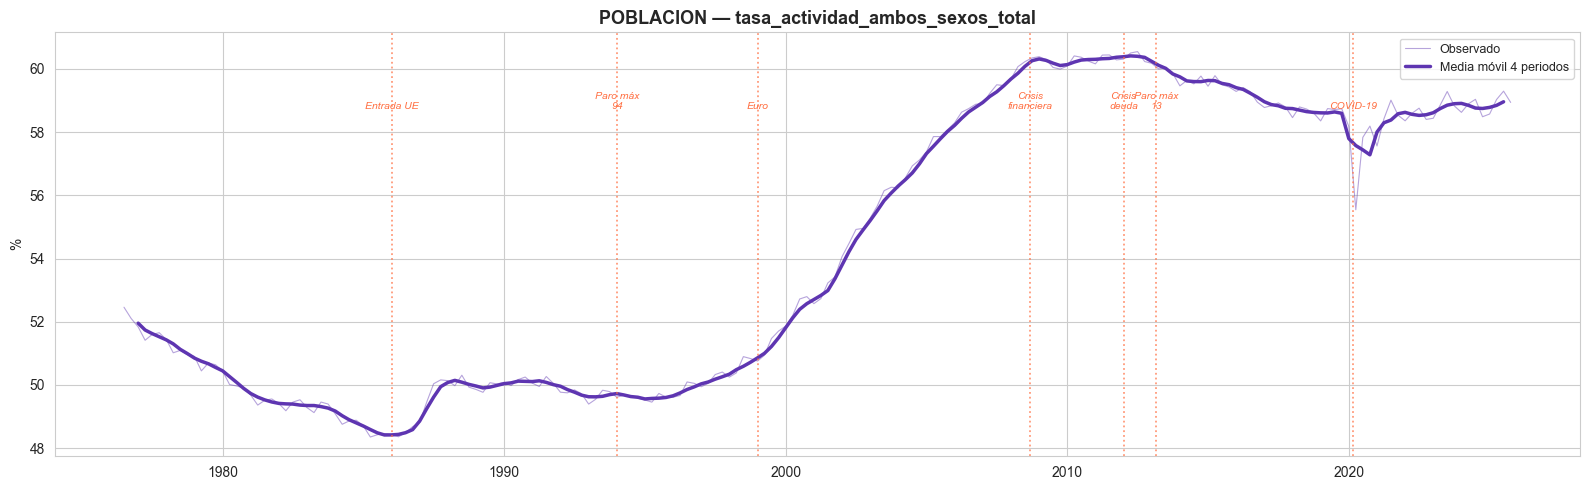

Mín: 48.35  (1985-04-01)
Máx: 60.55  (2012-07-01)


In [7]:
ventana_mm = PERIODO_ESTACIONAL

fig, ax = plt.subplots(figsize=(16, 5))

y = df[VAR_PRINCIPAL].dropna()
mm = y.rolling(ventana_mm, center=True).mean()

ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=0.8, alpha=0.45, label='Observado')
ax.plot(y.index, mm, color=COLOR_PRINCIPAL, lw=2.5,
        label=f'Media móvil {ventana_mm} periodos')

y_max = y.max()
for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if y.index.min() <= fecha_ev <= y.index.max():
        ax.axvline(fecha_ev, color='#FF7043', linestyle=':', lw=1.3, alpha=0.7)
        ax.text(fecha_ev, y_max * 0.97, texto,
                ha='center', fontsize=7.5, color='#FF7043', fontstyle='italic')

ax.set_title(f'{NOMBRE.upper()} — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')
ax.set_ylabel(UNIDADES, fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Mín: {y.min():.2f}  ({y.idxmin().date()})')
print(f'Máx: {y.max():.2f}  ({y.idxmax().date()})')

### Análisis:

La tasa de actividad está dominada por un ascenso estructural que la lleva de una meseta baja en torno al 50% a una meseta alta cercana al 60%, sin reversión a un nivel de equilibrio. La serie arranca en aproximadamente 52,4% en 1977 y desciende de forma leve hasta su mínimo de 48,35% en 1985-Q2; se recupera con rapidez hasta el entorno del 50% y permanece en esa meseta baja hasta mediados de los 90. A partir de 1997 inicia un ascenso intenso y sostenido que culmina en el máximo de 60,55% en 2012-Q3, tras el cual la serie corrige levemente hacia el 58-59%, con una caída abrupta y transitoria en 2020-Q2 al confinamiento, hasta aproximadamente 55,7%, recuperada en los trimestres siguientes. El recorrido total entre mínimo y máximo supera los 12 puntos porcentuales.

El perfil refleja la incorporación femenina como motor estructural: la meseta baja de los 80 y primeros 90 corresponde a una fase en que la entrada de mujeres aún no compensaba la salida de cohortes masculinas mayores, y el despegue desde 1997 coincide con la masa crítica de participación femenina y el ciclo expansivo. El máximo en plena crisis de 2012 es coherente con una participación que se sostiene incluso cuando el empleo se desploma. La serie presenta no estacionariedad clara: tendencia dominante sin nivel de equilibrio, lo que anticipa no rechazo de raíz unitaria en ADF y rechazo de estacionariedad en KPSS en niveles.

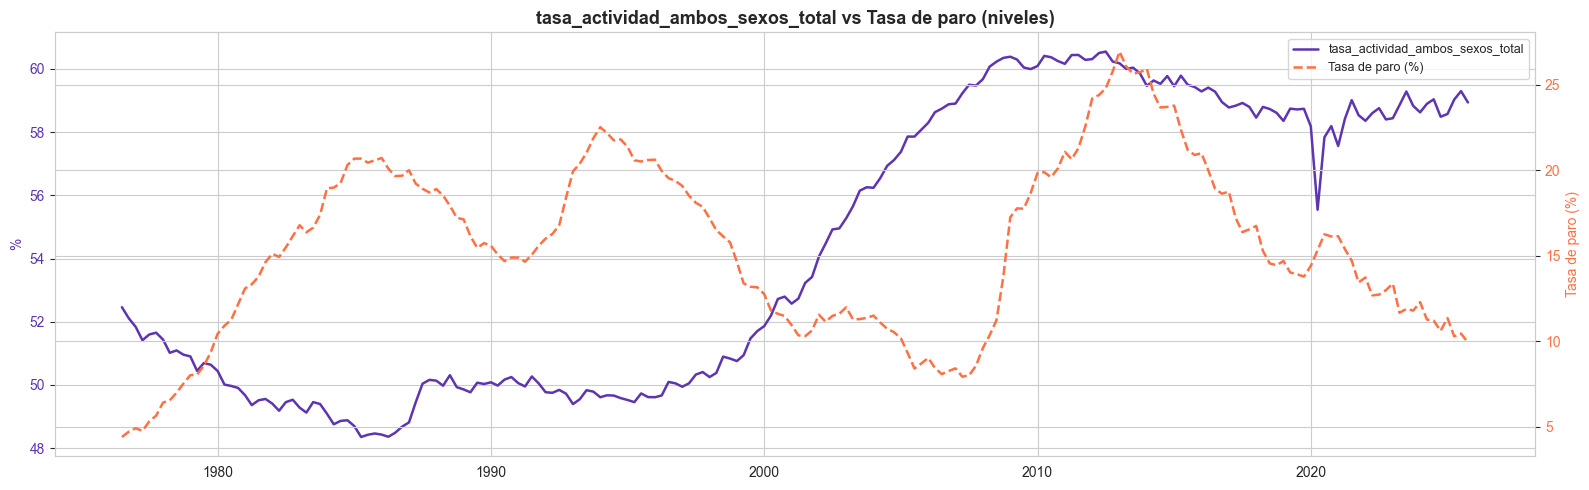

In [8]:
# Comparación de niveles con la tasa de paro (antes de analizar estacionariedad)
ruta_paro_s2 = RUTA_BASE / 'parados_sexo_edad.csv'
df_paro_s2 = pd.read_csv(ruta_paro_s2)
df_paro_s2['fecha'] = pd.to_datetime(df_paro_s2['fecha'])
df_paro_s2 = df_paro_s2.set_index('fecha').sort_index()
tasa_paro_s2 = pd.to_numeric(df_paro_s2['tasa_paro_ambos_sexos_total'], errors='coerce').dropna()

y = df[VAR_PRINCIPAL].dropna()

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
ax1.plot(y.index, y, color=COLOR_PRINCIPAL, lw=1.8, label=VAR_PRINCIPAL)
ax2.plot(tasa_paro_s2.index, tasa_paro_s2, color='#FF7043', lw=1.8, linestyle='--', label='Tasa de paro (%)')
ax1.set_ylabel(UNIDADES, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')
ax1.set_title(f'{VAR_PRINCIPAL} vs Tasa de paro (niveles)', fontsize=13, fontweight='bold')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc='best')
plt.tight_layout()
plt.show()


### Análisis:

La relación entre la tasa de actividad y la tasa de paro cambia de signo a lo largo del periodo, sin un vínculo contemporáneo estable. En el tramo inicial (1977-1985) ambas se mueven en sentido inverso: la actividad cae desde aproximadamente 52,4% hasta su mínimo de 48,35% mientras el paro asciende desde aproximadamente 4,5% hasta cerca del 21%. La relación inversa reaparece entre 1994 y 2007, cuando la actividad sube con fuerza y el paro retrocede desde aproximadamente 22,5% hasta el entorno del 8%.

El tramo 2008-2013 rompe ese patrón: la actividad se mantiene en su meseta máxima, próxima al 60%, al tiempo que el paro escala hasta aproximadamente 27%. La coincidencia de participación elevada y desempleo elevado es coherente con una oferta laboral que se sostiene durante la crisis en lugar de retirarse, hipótesis del trabajador añadido que el dato agregado no confirma por sí solo. Desde 2014 ambas series se relajan, con el paro descendiendo hasta aproximadamente 10% y la actividad estabilizándose en torno al 58-59%.

El contraste entre una tasa de actividad de trayectoria tendencial y una tasa de paro de comportamiento cíclico hace que el signo de la relación dependa del tramo considerado.

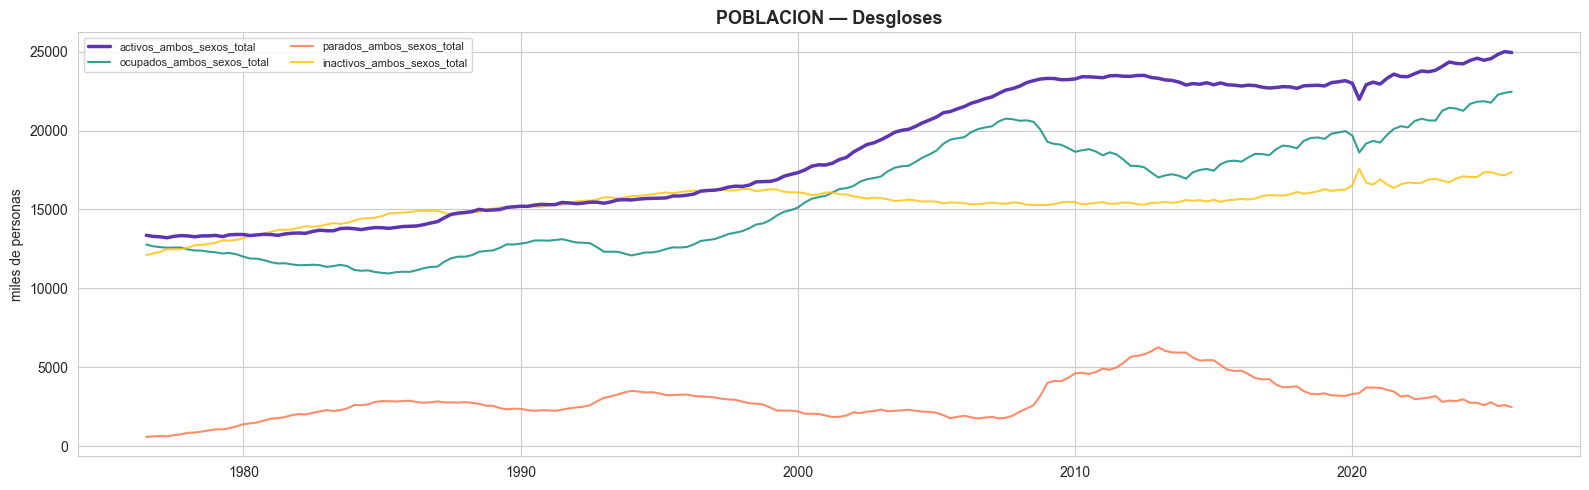

In [9]:
desgloses = [c for c in DATASET_CONFIG.get('variables_desgloses', []) if c in df.columns]

if desgloses:
    fig, ax = plt.subplots(figsize=(16, 5))
    VAR_ABSOLUTA = DATASET_CONFIG['variable_principal_absoluta']
    ax.plot(df[VAR_ABSOLUTA].dropna().index, df[VAR_ABSOLUTA].dropna(), color=COLOR_PRINCIPAL, lw=2.5, label=VAR_ABSOLUTA, zorder=5)

    for col, color in zip(desgloses, COLORES_DESGLOSES):
        serie = df[col].dropna()
        ax.plot(serie.index, serie, color=color, lw=1.5, alpha=0.8, label=col)

    ax.set_title(f'{NOMBRE.upper()} — Desgloses', fontsize=13, fontweight='bold')
    ax.set_ylabel(DATASET_CONFIG['unidades_absoluta'], fontsize=10)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

### Análisis:

Los cuatro componentes del mercado laboral revelan dinámicas estructurales de distinta naturaleza cuando se representan en valores absolutos sobre la misma escala. Los ocupados replican el perfil ascendente de la población activa pero con volatilidad cíclica marcadamente superior: caen de aproximadamente 20.500 a 17.000 miles entre 2008 y 2013, y de aproximadamente 20.000 a 17.000 miles en 2020-Q2, mientras que los activos apenas retroceden en esos mismos periodos. Esto confirma que los ajustes cíclicos del mercado laboral español operan fundamentalmente a través del empleo, no de la participación.

Los parados son la serie con mayor contenido cíclico del conjunto: parten de valores próximos a 700 miles en 1977, alcanzan un primer pico de aproximadamente 2.900 miles hacia 1985, se reducen hasta aproximadamente 2.200 miles en 2007, y se disparan hasta aproximadamente 6.000 miles en 2013, el máximo histórico de la serie. Su escala es un orden de magnitud inferior a la de activos y ocupados, lo que los hacía ilegibles en el gráfico anterior donde compartían eje con la tasa de paro. Representados en valores absolutos, los tres grandes ciclos de desempleo masivo documentados en el EDA de parados son perfectamente visibles.

Los inactivos crecen en términos absolutos de aproximadamente 12.500 a 17.000 miles entre 1977 y 2025, con una meseta entre 1995 y 2015 que refleja la absorción de inactivos hacia la actividad durante la expansión inmobiliaria. Su peso relativo sobre la población en edad de trabajar ha descendido estructuralmente, aunque esa ratio no es directamente visible en este panel de valores absolutos.

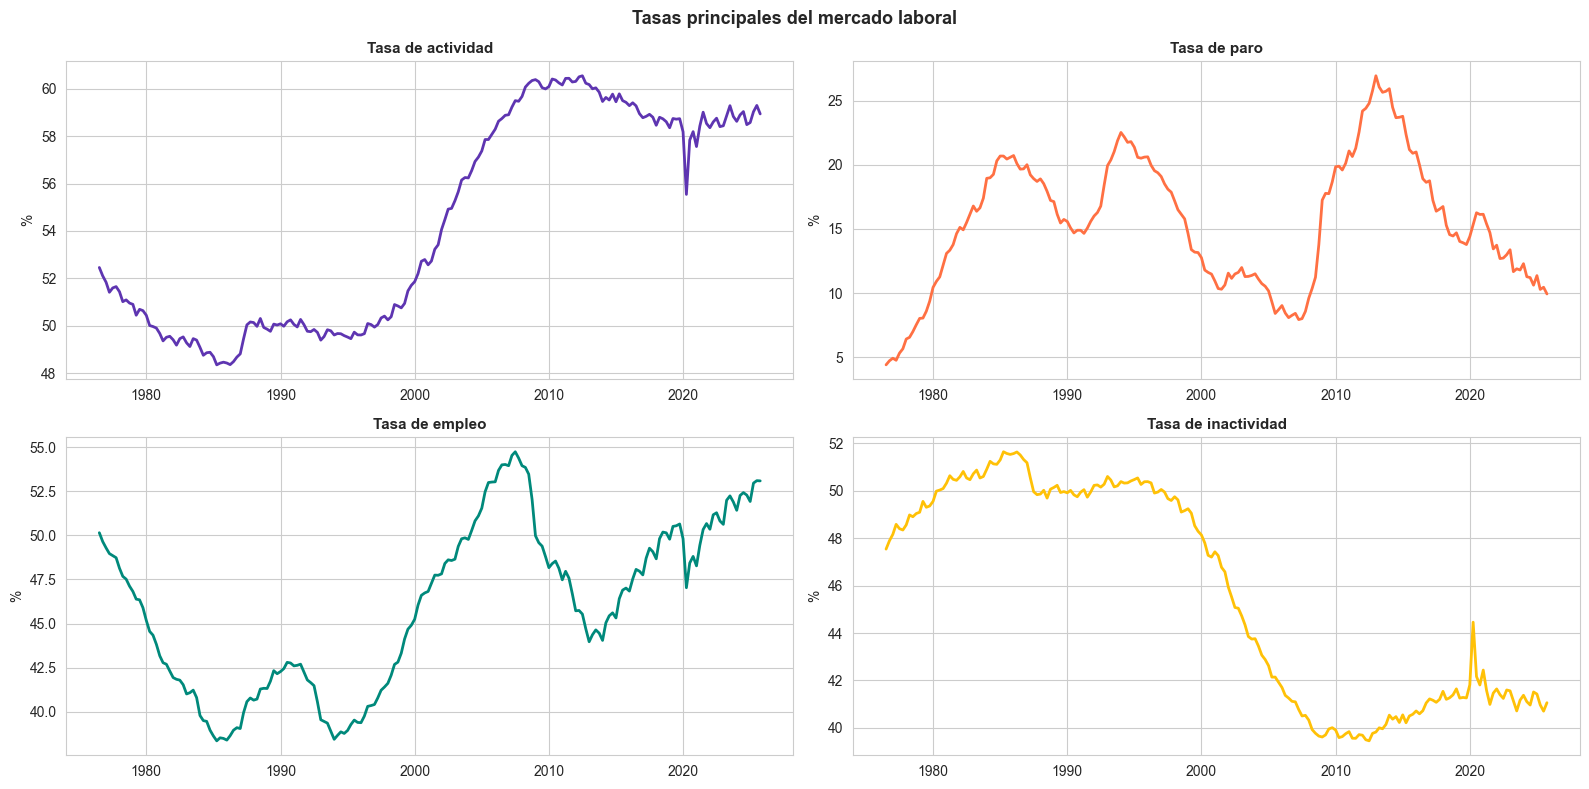

In [10]:
# Panel de tasas principales
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Tasas principales del mercado laboral', fontsize=13, fontweight='bold')

tasas = {
    'Tasa de actividad': 'tasa_actividad_ambos_sexos_total',
    'Tasa de paro': 'tasa_paro_ambos_sexos_total',
    'Tasa de empleo': 'tasa_empleo_ambos_sexos_total',
    'Tasa de inactividad': 'tasa_inactividad_ambos_sexos_total',
}
colores_tasas = [COLOR_PRINCIPAL, '#FF7043', '#00897B', '#FFC107']

for ax, (titulo, col), color in zip(axes.flatten(), tasas.items(), colores_tasas):
    if col in df.columns:
        serie = df[col].dropna()
        ax.plot(serie.index, serie, color=color, lw=2)
        ax.set_title(titulo, fontsize=11, fontweight='bold')
        ax.set_ylabel('%', fontsize=10)

plt.tight_layout()
plt.show()

### Análisis:

Las cuatro tasas del mercado laboral describen dinámicas estructurales de distinta naturaleza. La tasa de actividad está dominada por un ascenso estructural de una meseta baja a otra alta: aproximadamente 52% en 1977, descenso leve hasta el entorno del 48,5% en 1985, meseta en torno al 50% hasta mediados de los 90, y ascenso sostenido hasta una meseta de aproximadamente 60% entre 2008 y 2012, con leve corrección posterior hacia el 58-59%.

La tasa de paro es la única sin tendencia determinista: oscila entre aproximadamente 4,5% en 1977 y aproximadamente 27% en 2013, con tres ciclos completos de expansión y contracción (picos cercanos a 20,5% en 1985, 22,5% en 1994 y 27% en 2013). La amplitud creciente de los ciclos y la ausencia de un nivel de equilibrio estable hacen que su tratamiento como estacionaria sea discutible, con independencia de los tests formales. Este punto se desarrolla en la sección de estacionariedad.

La tasa de empleo amplifica el perfil cíclico: cae desde aproximadamente 50% en 1977 hasta aproximadamente 38,5% en 1985, recupera hasta aproximadamente 55% en 2007, retrocede a aproximadamente 44% en 2013, y se recupera hasta aproximadamente 53% al final. Es el indicador que mejor captura el ajuste cíclico del mercado laboral. La tasa de inactividad se mueve en sentido opuesto y descendente, desde aproximadamente 51,5% a mediados de los 80 hasta aproximadamente 40% en la década reciente, con la caída más pronunciada entre 1995 y 2009.

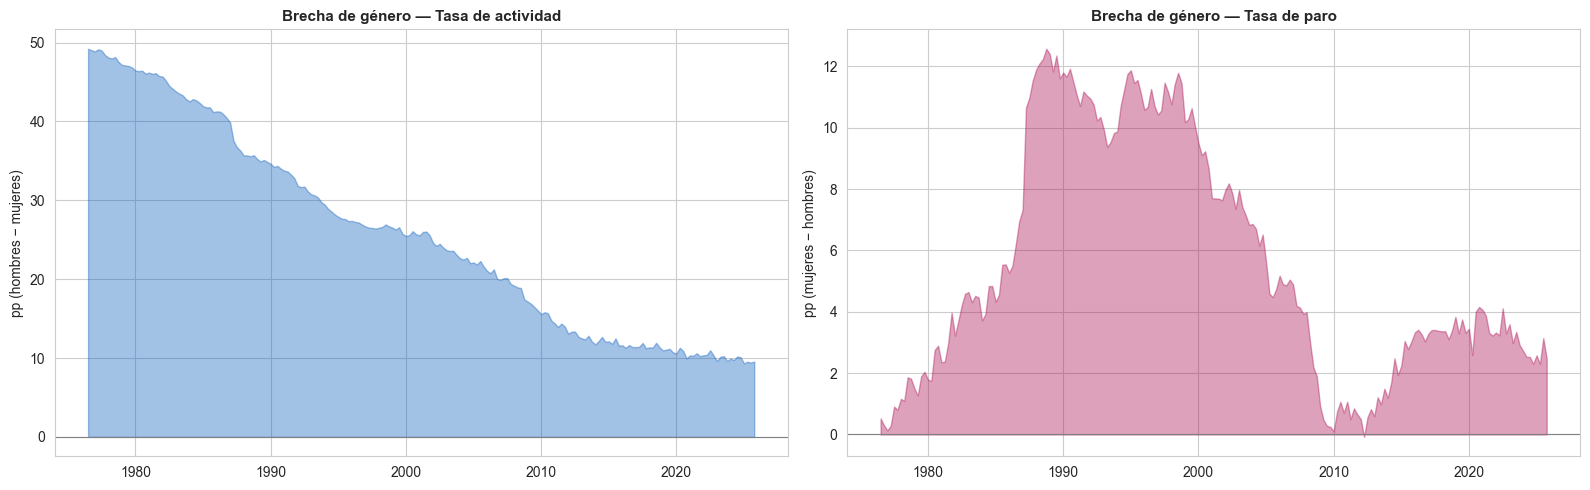

In [11]:
# Evolución de las brechas de género
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if 'brecha_genero_actividad' in df.columns:
    bg_act = df['brecha_genero_actividad'].dropna()
    axes[0].fill_between(bg_act.index, bg_act, 0, alpha=0.4, color='#1565C0')
    axes[0].axhline(0, color='gray', lw=0.8)
    axes[0].set_title('Brecha de género — Tasa de actividad', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('pp (hombres − mujeres)', fontsize=10)

if 'brecha_genero_paro' in df.columns:
    bg_paro = df['brecha_genero_paro'].dropna()
    axes[1].fill_between(bg_paro.index, bg_paro, 0, alpha=0.4, color='#AD1457')
    axes[1].axhline(0, color='gray', lw=0.8)
    axes[1].set_title('Brecha de género — Tasa de paro', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('pp (mujeres − hombres)', fontsize=10)

plt.tight_layout()
plt.show()

### Análisis:

La brecha de género en tasa de actividad se ha reducido de aproximadamente 49 puntos porcentuales en 1977 a aproximadamente 9-10 en 2025, una de las transformaciones estructurales más intensas del mercado laboral español en el periodo y el factor que en mayor medida explica el ascenso sostenido de la tasa de actividad agregada. La reducción no fue lineal: se mantuvo por encima de 35 pp hasta mediados de los 80, se aceleró entre 1990 y 2010, y se ha ralentizado después, lo que sugiere proximidad a un límite estructural.

La brecha de género en tasa de paro describe una dinámica distinta y no monótona. Desde valores próximos a cero en 1977 se amplía hasta un máximo de aproximadamente 12,5 pp hacia 1989-1990, con una segunda cresta similar a mediados de los 90, periodo en que las mujeres soportaban un desempleo sistemáticamente superior. A partir de ahí decrece y converge a valores próximos a cero hacia 2009-2012, coincidiendo con la destrucción de empleo en sectores masculinizados como construcción e industria. Desde mediados de la década pasada vuelve a ampliarse de forma moderada hasta aproximadamente 4 pp, lo que indica que la convergencia de 2009-2012 no fue permanente y que persisten disparidades por sector, jornada o modalidad contractual que este indicador agregado no descompone.

---
## 3. Distribución y Outliers

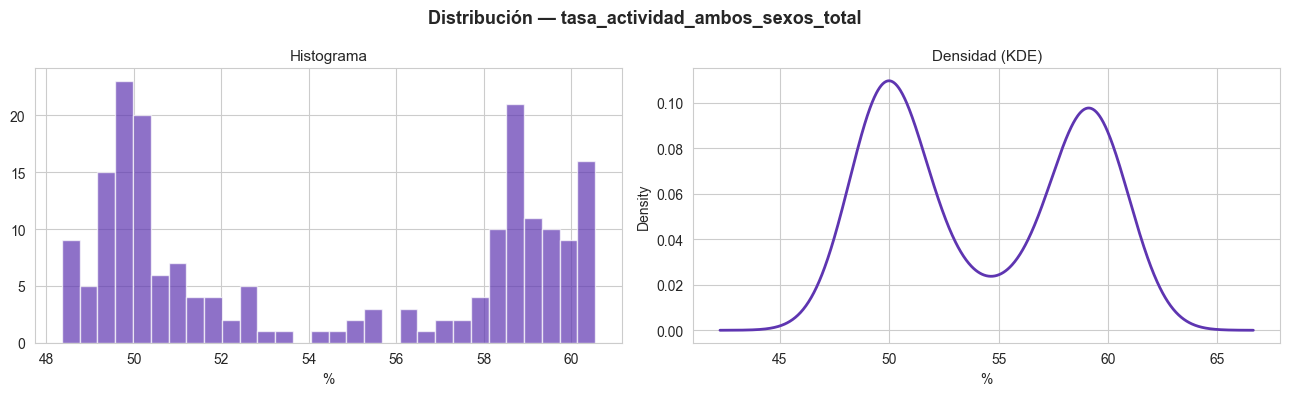

Asimetría (skewness): 0.101
Curtosis:             -1.788


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Distribución — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].hist(y, bins=30, color=COLOR_PRINCIPAL, alpha=0.7, edgecolor='white')
axes[0].set_xlabel(UNIDADES, fontsize=10)
axes[0].set_title('Histograma', fontsize=11)

y.plot.kde(ax=axes[1], color=COLOR_PRINCIPAL, lw=2)
axes[1].set_xlabel(UNIDADES, fontsize=10)
axes[1].set_title('Densidad (KDE)', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Asimetría (skewness): {y.skew():.3f}')
print(f'Curtosis:             {y.kurtosis():.3f}')

### Análisis:

La distribución de la tasa de actividad es marcadamente bimodal, con dos modos bien definidos en torno al 50% y al 59% y un valle intermedio en torno al 55%. Esta estructura no refleja una propiedad intrínseca de la variable sino el efecto de la trayectoria en U sobre la distribución marginal: la serie permaneció durante periodos prolongados en la meseta baja de aproximadamente 50% (años 80 y primeros 90) y en la meseta alta de aproximadamente 58-60% (desde 2008), mientras transitó con rapidez por los valores intermedios durante el ascenso de 1997-2008, acumulando pocas observaciones en ese rango.

La curtosis negativa (-1,788) confirma colas más ligeras y cima más plana que una normal, sin concentración en torno a un único valor central, y la asimetría es prácticamente nula (0,101). La distribución refleja la coexistencia de dos regímenes de participación laboral a lo largo del periodo, no una variable que gravite hacia un equilibrio único, lo que es coherente con la no estacionariedad de la serie.

In [13]:
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
limite_inf_iqr = Q1 - 1.5 * IQR
limite_sup_iqr = Q3 + 1.5 * IQR

z_scores = np.abs(stats.zscore(y.dropna()))
outliers_z = y[z_scores > 3]
outliers_iqr = y[(y < limite_inf_iqr) | (y > limite_sup_iqr)]

print(f'Outliers por IQR  (1.5×): {len(outliers_iqr)}')
print(f'Outliers por z-score (>3): {len(outliers_z)}')

extremos = pd.concat([
    y.nsmallest(5).rename('valor'),
    y.nlargest(5).rename('valor')
]).sort_values()

print('\n10 valores extremos (5 mínimos + 5 máximos):')
print(extremos.to_frame().reset_index().to_string(index=False))

Outliers por IQR  (1.5×): 0
Outliers por z-score (>3): 0

10 valores extremos (5 mínimos + 5 máximos):
     fecha  valor
1985-04-01 48.354
1986-04-01 48.362
1985-07-01 48.426
1986-01-01 48.429
1985-10-01 48.465
2010-04-01 60.411
2011-04-01 60.438
2011-07-01 60.442
2012-04-01 60.503
2012-07-01 60.548


### Análisis:

Ningún valor atípico detectado por IQR ni por z-score. Es coherente con una serie de trayectoria suave y sin reversiones bruscas: los extremos coinciden con los extremos temporales de la trayectoria, no con anomalías. Los cinco valores mínimos se concentran en 1985-1986 (entre 48,35% y 48,47%), fondo de la U, y los cinco máximos en 2010-2012 (entre 60,41% y 60,55%), techo de la meseta alta.

La ausencia de outliers refleja una propiedad económica relevante: la participación laboral es una decisión de horizonte largo, poco sensible a perturbaciones cíclicas. El efecto trabajador desanimado, que retira personas de la búsqueda activa, y el efecto trabajador añadido, que incorpora miembros secundarios del hogar ante la caída de ingresos del sustentador principal, operan en sentidos opuestos y tienden a compensarse en el agregado. El resultado es que la tasa de actividad apenas registra choques incluso durante la recesión de 2008-2013; de hecho su máximo histórico se sitúa en 2012-Q3, en plena crisis, mientras el empleo se desplomaba. Esto contrasta con los parados, donde los ajustes cíclicos sí generaban valores extremos por IQR.

In [14]:
if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
    y_periodo = y.index.quarter.map({1:'T1', 2:'T2', 3:'T3', 4:'T4'})
    titulo_grupo = 'Trimestre'
    orden_periodos = ['T1', 'T2', 'T3', 'T4']
elif DATASET_CONFIG['frecuencia_original'] == 'mensual':
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses
else:
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses

colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
               '#1565C0', '#AD1457', '#2E7D32', '#E65100',
               '#6A1B9A', '#00695C', '#F57F17', '#37474F']

df_box = pd.DataFrame({
    'periodo': y_periodo.values,
    'valor': y.values,
    'fecha': y.index.strftime('%Y-%m-%d'),
})
df_box['periodo'] = pd.Categorical(df_box['periodo'],
                                    categories=[p for p in orden_periodos if p in df_box['periodo'].values],
                                    ordered=True)

fig = px.box(
    df_box, x='periodo', y='valor', color='periodo',
    hover_data=['fecha'],
    title=f'Distribución por {titulo_grupo} — {VAR_PRINCIPAL}',
    labels={'valor': UNIDADES, 'periodo': titulo_grupo, 'fecha': 'Fecha'},
    color_discrete_sequence=colores_bp,
    category_orders={'periodo': orden_periodos},
)
fig.update_layout(showlegend=False, height=420)
fig.show()

### Análisis:

Las medianas y rangos intercuartílicos de los cuatro trimestres son prácticamente indistinguibles, sin separación apreciable entre cajas, lo que confirma la ausencia de patrón estacional relevante en la tasa de actividad y anticipa índices estacionales próximos a la unidad. Las decisiones de participación son de horizonte largo y no responden al calendario trimestral. La amplia dispersión común a los cuatro trimestres no refleja variabilidad estacional ni cíclica sino la trayectoria en U de gran amplitud, que hace que observaciones del mismo trimestre en distintos años disten hasta aproximadamente 12 puntos porcentuales entre sí, desde el entorno del 48% en los 80 hasta el 60% de la meseta reciente.

---
## 4. Estacionalidad

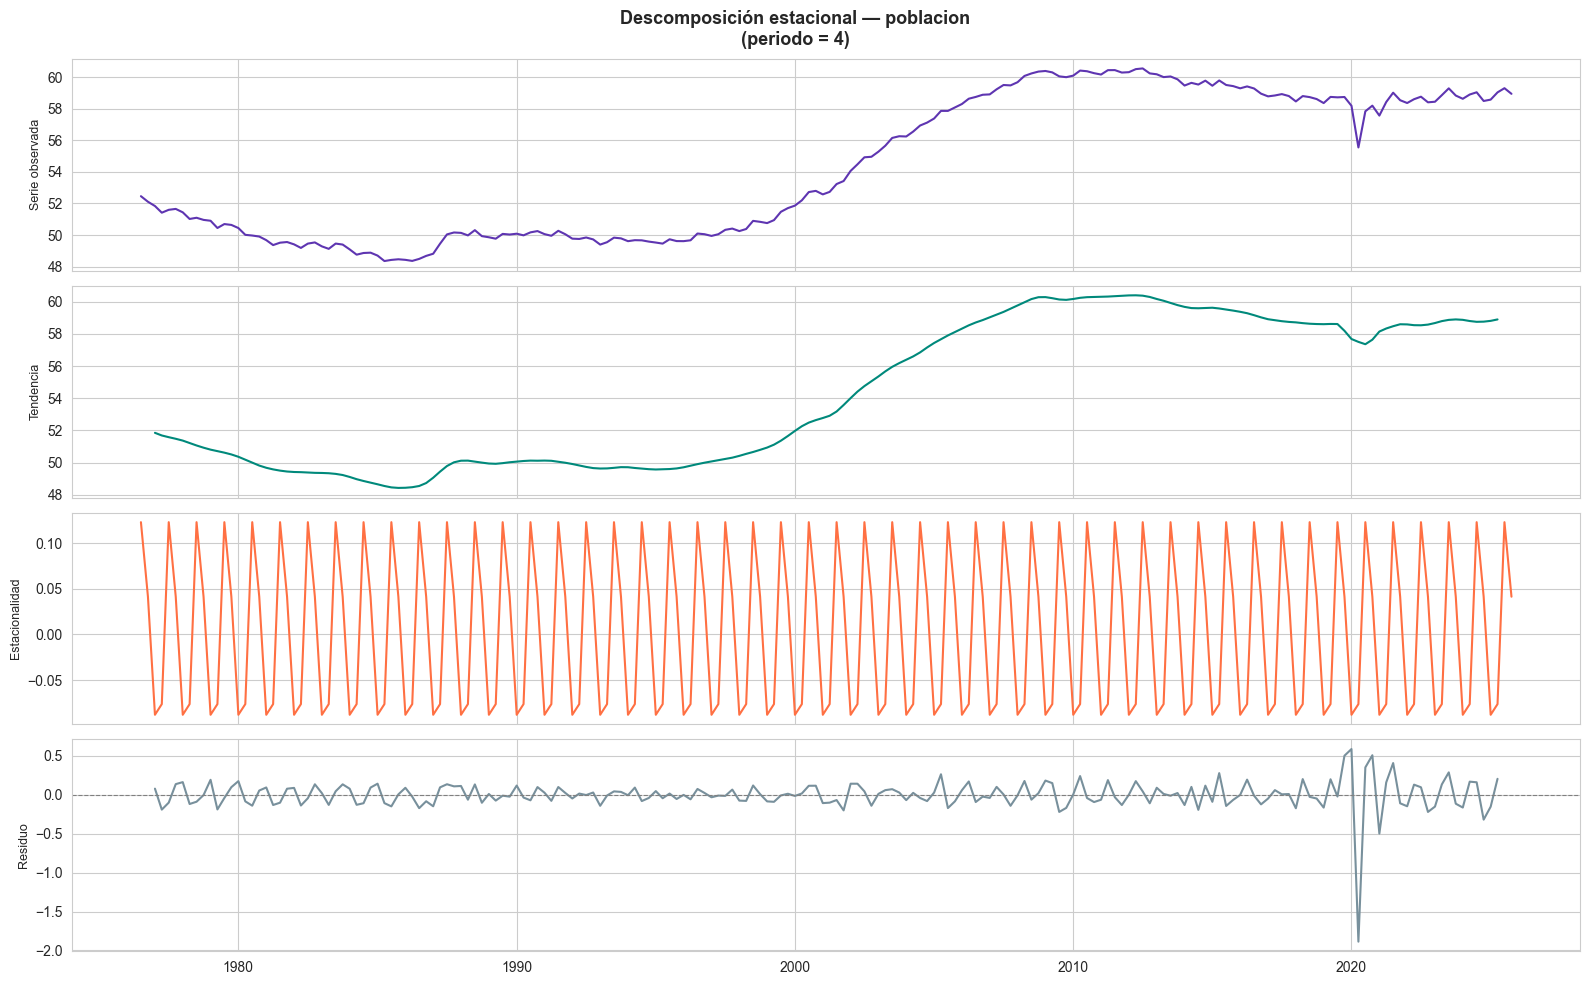

In [15]:
y_descomp = y.dropna()

if len(y_descomp) >= 2 * PERIODO_ESTACIONAL:
    descomp = seasonal_decompose(y_descomp, model='additive', period=PERIODO_ESTACIONAL)

    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f'Descomposición estacional — {NOMBRE}\n(periodo = {PERIODO_ESTACIONAL})',
                 fontsize=13, fontweight='bold')

    componentes = [
        ('Serie observada', descomp.observed, COLOR_PRINCIPAL),
        ('Tendencia', descomp.trend, '#00897B'),
        ('Estacionalidad', descomp.seasonal, '#FF7043'),
        ('Residuo', descomp.resid, '#78909C'),
    ]

    for ax, (titulo, datos, color) in zip(axes, componentes):
        ax.plot(datos.index, datos, color=color, lw=1.5)
        ax.set_ylabel(titulo, fontsize=9)
        if titulo == 'Residuo':
            ax.axhline(0, color='gray', linestyle='--', lw=0.8)

    plt.tight_layout()
    plt.show()
else:
    print(f'Serie demasiado corta para descomposición (necesita ≥ {2*PERIODO_ESTACIONAL} obs, tiene {len(y_descomp)})')

### Análisis:

La descomposición confirma que el componente de tendencia domina la serie, reproduciendo la U completa desde aproximadamente 48,5% en 1985 hasta aproximadamente 60,3% en la meseta de 2008-2012. El componente estacional es de amplitud reducida y constante, de aproximadamente ±0,1 puntos, lo que valida el modelo aditivo pero resulta marginal frente al rango de aproximadamente 12 puntos de la tendencia, coherente con la ausencia de separación entre cajas en el boxplot trimestral.

Los residuos son pequeños y están centrados en cero durante casi todo el periodo, con oscilaciones habituales inferiores a aproximadamente ±0,3 puntos. El valor extremo absoluto corresponde a 2020-Q2, con un residuo de aproximadamente -1,9 puntos, reflejo de la caída abrupta de la participación durante el confinamiento que ningún componente sistemático captura, seguido de un rebote positivo en el trimestre siguiente. Fuera de ese episodio no se aprecia un aumento sostenido de la volatilidad residual que sugiera un cambio estructural en la varianza.

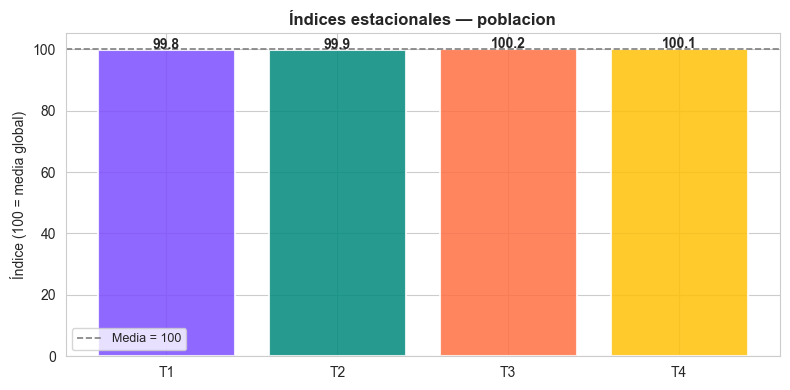

Índices estacionales:
T1    99.800
T2    99.900
T3   100.200
T4   100.100

Periodo con mayor poblacion: T3 (100.2)
Periodo con menor poblacion: T1 (99.8)


In [16]:
if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):

    if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
        grupo_idx = y.index.quarter
        etiq_idx = ['T1', 'T2', 'T3', 'T4']
    else:
        grupo_idx = y.index.month
        etiq_idx = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

    media_por_periodo = pd.Series(
        {p: y[grupo_idx == p].mean() for p in sorted(np.unique(grupo_idx))}
    )
    indice_estacional = (media_por_periodo / media_por_periodo.mean() * 100).round(1)
    indice_estacional.index = etiq_idx[:len(indice_estacional)]

    fig, ax = plt.subplots(figsize=(8, 4))
    colores_idx = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
                   '#1565C0', '#AD1457', '#2E7D32', '#E65100',
                   '#6A1B9A', '#00695C', '#F57F17', '#37474F']
    barras = ax.bar(indice_estacional.index, indice_estacional.values,
                    color=colores_idx[:len(indice_estacional)], edgecolor='white',
                    linewidth=1.5, alpha=0.85)
    ax.axhline(100, color='gray', linestyle='--', lw=1.2, label='Media = 100')
    ax.set_title(f'Índices estacionales — {NOMBRE}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Índice (100 = media global)', fontsize=10)
    for b, v in zip(barras, indice_estacional.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Índices estacionales:')
    print(indice_estacional.to_string())
    print(f'\nPeriodo con mayor {NOMBRE}: {indice_estacional.idxmax()} ({indice_estacional.max():.1f})')
    print(f'Periodo con menor {NOMBRE}: {indice_estacional.idxmin()} ({indice_estacional.min():.1f})')

### Análisis:

Los índices estacionales son T1=99,8, T2=99,9, T3=100,2 y T4=100,1. La diferencia entre el trimestre más alto (T3) y el más bajo (T1) es de 0,4 puntos sobre base 100, que sobre el nivel medio de la serie equivale a una oscilación de aproximadamente 0,2 puntos porcentuales de tasa. Es una estacionalidad estadísticamente detectable pero económicamente irrelevante, coherente con la ausencia de diferencias entre cajas en el boxplot trimestral y con la amplitud reducida del componente estacional en la descomposición.

El patrón T3 alto y T1 bajo es compatible con un leve efecto de calendario en la participación, ligeramente superior en el tercer trimestre. La magnitud es tan reducida que, a efectos prácticos, la tasa de actividad puede considerarse una serie sin estacionalidad significativa.

---
## 5. Cambios Periodo a Periodo

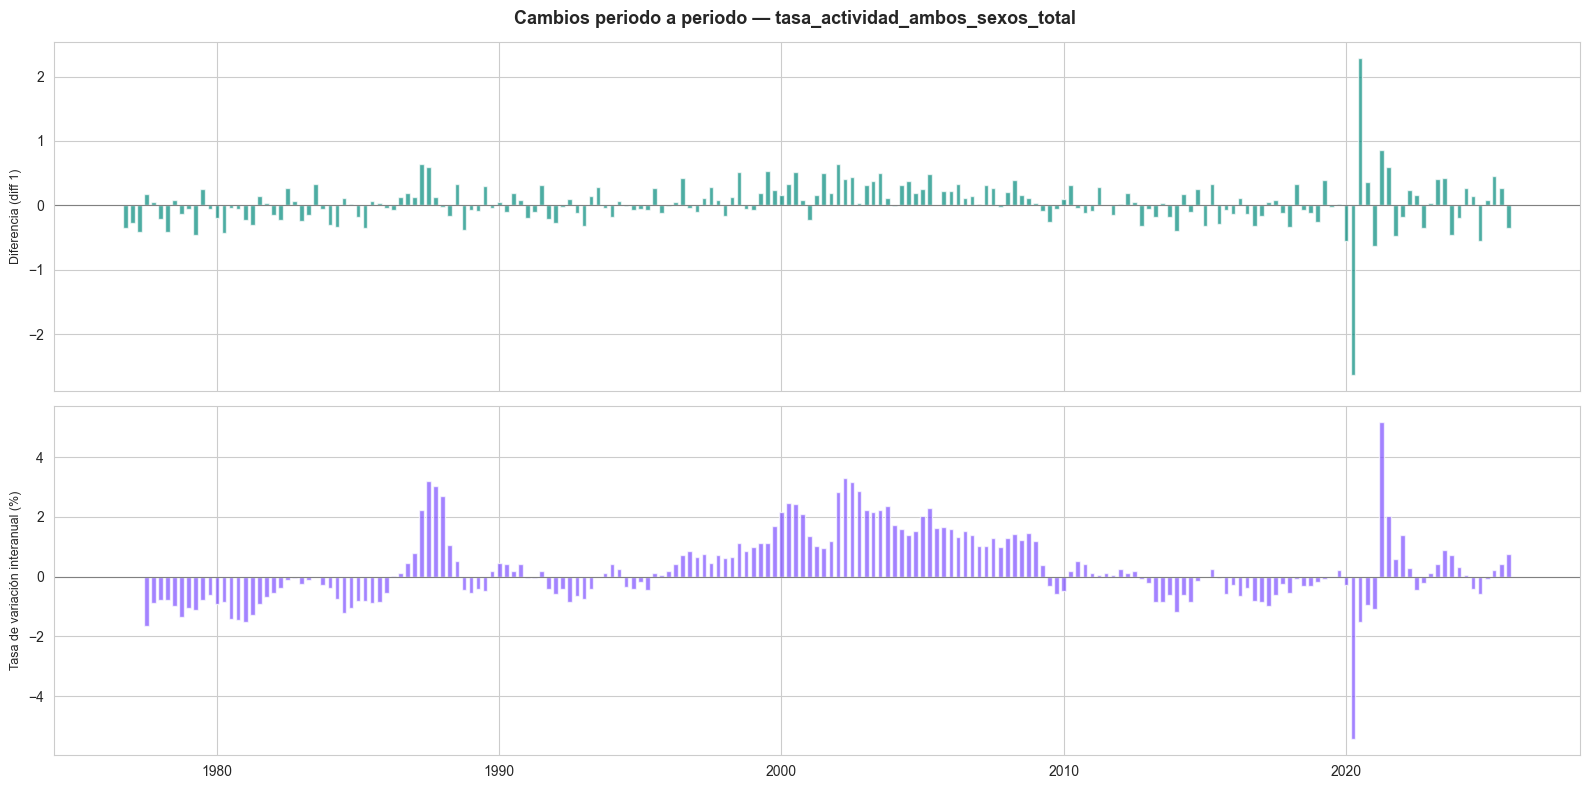

Estadísticas de la variación interanual (%):
count   194.000
mean      0.270
std       1.200
min      -5.450
25%      -0.550
50%       0.070
75%       0.990
max       5.180


In [17]:
diff1 = y.diff(1).dropna()
diff_est = y.diff(PERIODO_ESTACIONAL).dropna()  # se usa en Sección 6 (stationarity test)
pct_yoy = y.pct_change(PERIODO_ESTACIONAL).dropna() * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Cambios periodo a periodo — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].bar(diff1.index, diff1, color='#00897B', alpha=0.7, width=60)
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_ylabel('Diferencia (diff 1)', fontsize=9)

axes[1].bar(pct_yoy.index, pct_yoy, color='#7C4DFF', alpha=0.7, width=60)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_ylabel('Tasa de variación interanual (%)', fontsize=9)

plt.tight_layout()
plt.show()

print('Estadísticas de la variación interanual (%):')
print(pct_yoy.describe().round(2).to_string())

### Análisis:

La primera diferencia de la tasa de actividad oscila en torno a cero con amplitud contenida, mayoritariamente dentro de un rango de aproximadamente ±0,5 puntos, sin sesgo marcado salvo una ligera predominancia de incrementos durante la fase de ascenso de 1997-2008. Los únicos valores que salen con claridad de ese rango corresponden a 2020-Q2 (caída de aproximadamente -2,6 puntos durante el confinamiento) y a su rebote inmediato en 2020-Q3 (aproximadamente +2,3 puntos), ambos magnitudes aproximadas leídas contra la cuadrícula.

La variación interanual presenta una media de 0,27% y una mediana de 0,07%, con el cuartil inferior en -0,55% y el superior en 0,99%, lo que confirma que el crecimiento neto de la tasa de actividad es muy débil en promedio y refleja una serie que ha alcanzado una meseta, no un crecimiento sostenido. La distribución es ligeramente asimétrica positiva: la media supera a la mediana en 20 puntos básicos, y los extremos corresponden a 2020-Q2 (-5,45%, confinamiento) y 2021-Q2 (5,18%, rebote post-confinamiento). Los tramos de variación interanual claramente positiva se concentran en 1997-2008 (incorporación femenina e inmigratoria), mientras que 1977-1986 y el periodo posterior a 2008 muestran variaciones predominantemente nulas o negativas.

---
## 6. Estacionariedad y Autocorrelación

In [18]:
def test_estacionariedad(serie, nombre_serie, regression='c'):
    s = serie.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags='auto')
    estacionaria = (adf_p < 0.05) and (kpss_p >= 0.05)
    return {
        'serie': nombre_serie,
        'regression': regression,
        'ADF_stat': round(adf_stat, 4),
        'ADF_p': round(adf_p, 4),
        'ADF_H0_rechaza': adf_p < 0.05,
        'KPSS_stat': round(kpss_stat, 4),
        'KPSS_p': round(kpss_p, 4),
        'KPSS_H0_rechaza': kpss_p < 0.05,
        'conclusion': 'ESTACIONARIA' if estacionaria else 'NO ESTACIONARIA',
    }

series_test = [
    (y, f'{VAR_PRINCIPAL} (nivel)', 'ct'),
    (diff1, f'{VAR_PRINCIPAL} (diff 1)', 'c'),
    (diff_est, f'{VAR_PRINCIPAL} (diff {PERIODO_ESTACIONAL})', 'c'),
]

resultados_est = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test])

print('Tests de estacionariedad:')
print('=' * 85)
print(resultados_est.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_est.iterrows():
    h0_adf = 'rechaza H\u2080' if row['ADF_H0_rechaza'] else 'NO rechaza H\u2080'
    h0_kpss = 'rechaza H\u2080' if row['KPSS_H0_rechaza'] else 'NO rechaza H\u2080'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  (H\u2080 = ra\u00edz unitaria):  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS (H\u2080 = estacionaria):   stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    \u2192 {row['conclusion']}")
    print()

Tests de estacionariedad:
                                    serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
 tasa_actividad_ambos_sexos_total (nivel)         ct    -1.070  0.727           False      0.239   0.010             True NO ESTACIONARIA
tasa_actividad_ambos_sexos_total (diff 1)          c    -2.682  0.077           False      0.517   0.038             True NO ESTACIONARIA
tasa_actividad_ambos_sexos_total (diff 4)          c    -1.974  0.298           False      0.358   0.095            False NO ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  tasa_actividad_ambos_sexos_total (nivel)  (KPSS regression='ct')
    ADF  (H₀ = raíz unitaria):  stat=-1.070, p=0.7269 (NO rechaza H₀)
    KPSS (H₀ = estacionaria):   stat=0.239, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  tasa_actividad_ambos_sexos_total (diff 1)  (KPSS regression='c')
    ADF  (H₀ = raíz unitaria):  stat=-2.682, p=0.0772 (NO recha

### Análisis:

Los tres niveles de transformación producen el diagnóstico de NO estacionaria. El ADF contrasta la hipótesis nula de raíz unitaria y el KPSS la hipótesis opuesta de estacionariedad; su aplicación conjunta permite un diagnóstico más robusto que cada test por separado.

En niveles, ambos tests convergen: el ADF no rechaza la raíz unitaria (stat=-1,070, p=0,727) y el KPSS rechaza la estacionariedad (stat=0,239, p=0,010), señalando inequívocamente no estacionariedad, coherente con la trayectoria en U sin reversión a la media documentada en secciones anteriores.

En primera diferencia el diagnóstico sigue siendo no estacionaria, y de forma informativa: el ADF se acerca al umbral pero no rechaza la raíz unitaria al 5% (stat=-2,682, p=0,077) y el KPSS rechaza la estacionariedad (stat=0,517, p=0,038). Que el KPSS rechace tras diferenciar indica que una única diferencia regular no elimina toda la estructura no estacionaria, atribuible a que la velocidad de cambio de la participación no es constante: nula en las mesetas y elevada en el ascenso de 1997-2008.

En diferencia estacional, ninguno de los dos tests rechaza su hipótesis nula (ADF stat=-1,974, p=0,298; KPSS stat=0,358, p=0,095), resultado no concluyente que por criterio conservador se clasifica como no estacionaria, en contraste con los parados, donde diff(4) alcanzaba estacionariedad limpia. La forma estacionaria adecuada para esta variable se determina en feature engineering.

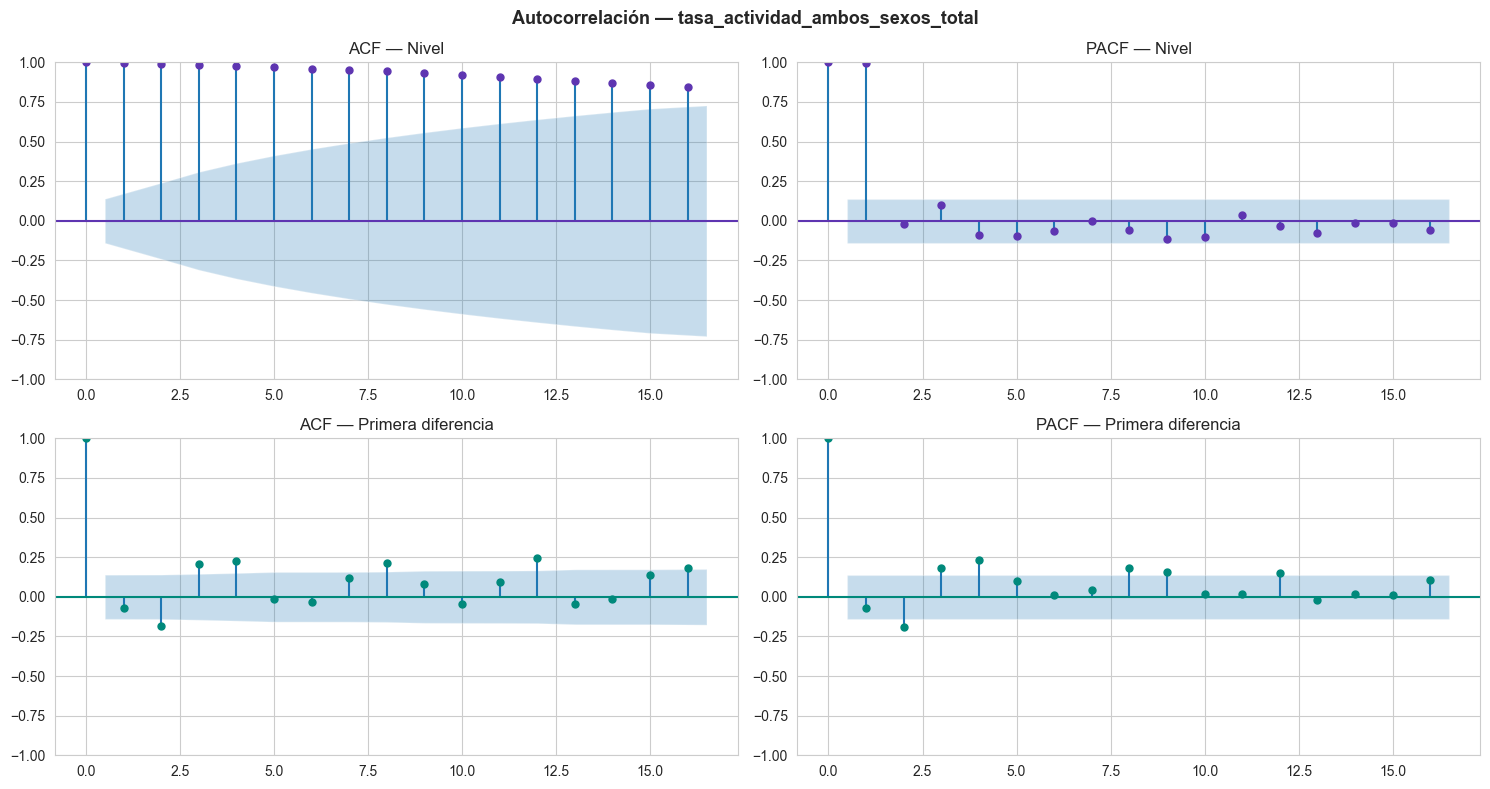

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(f'Autocorrelación — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel')
plot_pacf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel', method='ywm')
plot_acf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 0], color='#00897B',
         title='ACF — Primera diferencia')
plot_pacf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 1], color='#00897B',
          title='PACF — Primera diferencia', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

En niveles, el ACF presenta un decaimiento extremadamente lento, con autocorrelación en lag 1 próxima a 1 que apenas desciende hasta aproximadamente 0,83 en lag 16. Esta firma es característica de una serie con raíz unitaria y confirma visualmente el diagnóstico de no estacionariedad de los tests formales (ADF p=0,727, KPSS p=0,010). El PACF en niveles muestra un pico dominante en lag 1 y valores en su mayoría dentro de las bandas a partir de lag 2, firma de raíz cercana a la unidad.

En primera diferencia, el ACF se reduce drásticamente pero no entra del todo en las bandas: se observan picos significativos en lag 2 (negativo, de aproximadamente -0,19) y en lags 3-4 (positivos, de aproximadamente 0,20-0,23), junto a repuntes en lags 8 y 12. El PACF de la diferencia presenta un patrón análogo. La presencia de picos en lags múltiplos de 4 indica una estructura estacional trimestral residual leve, coherente con el componente estacional no nulo detectado en la descomposición y a diferencia de la población activa, donde esa estructura estaba ausente. La persistencia de autocorrelaciones fuera de las bandas es coherente con el rechazo del KPSS en primera diferencia (p=0,038) y refuerza que una única diferenciación regular no estabiliza completamente la serie.

---
## 7. Variables Derivadas Intra-Dataset
Ratios y transformaciones calculadas a partir de las columnas de este dataset.

In [20]:
df_der = pd.DataFrame(index=df.index)

if all(c in df.columns for c in ['inactivos_ambos_sexos_total', 'activos_ambos_sexos_total']):
    df_der['ratio_dependencia'] = df['inactivos_ambos_sexos_total'] / df['activos_ambos_sexos_total'] * 100

if all(c in df.columns for c in ['tasa_paro_ambos_sexos_menos_de_25', 'tasa_paro_ambos_sexos_25_o_mas']):
    df_der['ratio_paro_juvenil_adulto'] = df['tasa_paro_ambos_sexos_menos_de_25'] / df['tasa_paro_ambos_sexos_25_o_mas']

if all(c in df.columns for c in ['tasa_actividad_mujeres_total', 'tasa_actividad_hombres_total']):
    df_der['convergencia_actividad'] = df['tasa_actividad_mujeres_total'] - df['tasa_actividad_hombres_total']

print(f'Variables derivadas creadas ({len(df_der.columns)}):')
display(df_der.describe().round(3))

Variables derivadas creadas (3):


,ratio_dependencia,ratio_paro_juvenil_adulto,convergencia_actividad
count,198.000,198.000,198.000
mean,85.325,2.773,-25.876
std,15.179,0.592,12.774
min,65.159,2.217,-49.226
25%,69.924,2.371,-35.506
50%,89.524,2.510,-25.583
75%,100.174,2.918,-12.541
max,106.810,4.448,-9.317


### Análisis:

Se construyen tres variables derivadas que capturan dimensiones estructurales del mercado laboral no visibles en las series en bruto.

El `ratio_dependencia` (inactivos sobre activos, en porcentaje) presenta una media de 85,3% y un rango de 65,2% a 106,8%. El máximo de 106,8% corresponde al inicio de la serie, cuando la población inactiva superaba a la activa, reflejo de una sociedad con participación femenina muy reducida y cohortes masculinas mayores fuera del mercado. La tendencia estructural descendente de esta ratio documenta la expansión progresiva de la base productiva de la economía a lo largo del periodo muestral, coherente con el crecimiento de activos y la reducción de inactivos relativos documentados en secciones anteriores.

El `ratio_paro_juvenil_adulto` presenta una media de 2,773 y una mediana de 2,510, con el 75% de las observaciones por debajo de 2,918. La asimetría positiva entre media y mediana, y el máximo de 4,448, indican que los episodios de crisis elevan desproporcionadamente el paro juvenil respecto al adulto, mientras que en periodos de expansión la ratio converge hacia su valor mínimo de 2,217. El umbral de 2 veces como mínimo histórico sugiere una penalización estructural permanente sobre el empleo juvenil independiente del ciclo.

La `convergencia_actividad` (tasa de actividad femenina menos masculina) es negativa en toda la muestra, con valores entre -49,2 pp y -9,3 pp y una mediana de -25,6 pp. La evolución desde el extremo inferior hasta valores próximos a -9 pp es consistente con la reducción de la brecha de género en actividad documentada en la sección de brechas, donde se cuantificó un descenso de aproximadamente 49 a 9 puntos porcentuales entre 1977 y 2025.

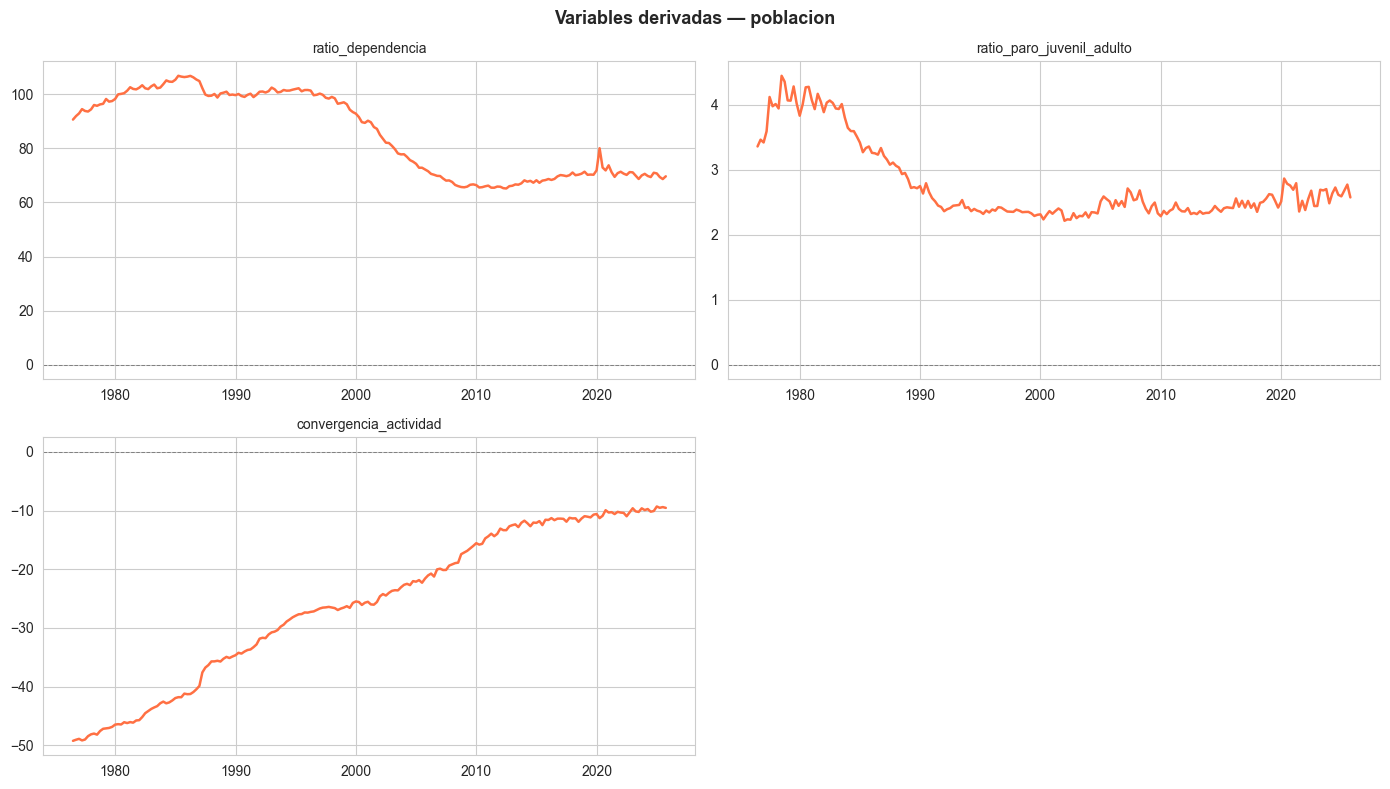

In [21]:
if not df_der.empty and len(df_der.columns) > 0:
    ncols = min(2, len(df_der.columns))
    nrows = (len(df_der.columns) + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(f'Variables derivadas — {NOMBRE}', fontsize=13, fontweight='bold')

    for ax, col in zip(axes, df_der.columns):
        serie = df_der[col].dropna()
        ax.plot(serie.index, serie, color='#FF7043', lw=1.8)
        ax.axhline(0, color='gray', lw=0.7, linestyle='--')
        ax.set_title(col, fontsize=10)

    for ax in axes[len(df_der.columns):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

### Análisis:

El `ratio_dependencia` confirma visualmente la tendencia descendente estructural: parte de valores superiores a 100 en los años 70, cuando los inactivos superaban a los activos, y se estabiliza en torno a 65-70 en la década reciente. El descenso es especialmente pronunciado entre 1985 y 2008, coincidiendo con el periodo de máxima incorporación femenina y el ciclo inmigratorio, y se interrumpe brevemente en 2020 por el efecto del confinamiento sobre la participación.

El `ratio_paro_juvenil_adulto` presenta un perfil más cíclico. Alcanza su máximo histórico de 4,448 en torno a 1980-1982, cuando la reconversión industrial destruía empleo de forma concentrada en sectores con alta presencia juvenil. Desde entonces desciende de forma estructural hasta estabilizarse en torno a 2,5 a partir de los años 2000, con repuntes moderados en las crisis de 2008-2013 y 2020. La reducción estructural no refleja un cambio demográfico en los stocks de población sino una menor brecha entre tasas: los jóvenes actuales, con mayor nivel educativo medio que los de los años 80, sufren una penalización relativa inferior, aunque el umbral mínimo observado de 2,217 confirma que esa penalización nunca desaparece.

La `convergencia_actividad` es la variable con mayor contenido estructural del conjunto: la brecha de participación entre sexos se cierra de forma casi lineal desde -49 pp en 1977 hasta aproximadamente -10 pp en la actualidad, sin inversiones ni aceleraciones bruscas salvo en el periodo 1995-2008. Como hipótesis no verificada, la incorporación femenina sostenida ampliaría la oferta agregada de trabajo y, en presencia de rigideces en la demanda, podría ejercer presión alcista sobre la tasa de paro a corto plazo, lo que le confiere potencial como variable explicativa.

In [22]:
# ── Guardar dataset enriquecido ───────────────────────────────────────────
if not df_der.empty:
    for col in df_der.columns:
        df[col] = df_der[col]
    df.to_csv(ruta)
    print(f'CSV sobreescrito: {ruta.name}')
    print(f'  {len(df_der.columns)} variables añadidas: {list(df_der.columns)}')
    print(f'  Columnas totales: {len(df.columns)}')
else:
    print('No se crearon variables derivadas.')

CSV sobreescrito: poblacion_relacion_actividad_economica_sexo_edad.csv
  3 variables añadidas: ['ratio_dependencia', 'ratio_paro_juvenil_adulto', 'convergencia_actividad']
  Columnas totales: 99


---
## 8. Tabla Resumen

In [23]:
est_nivel = resultados_est[resultados_est['serie'].str.contains('nivel')]['conclusion'].values[0]
est_diff1 = resultados_est[resultados_est['serie'].str.contains('diff 1')]['conclusion'].values[0]

if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):
    idx_max = indice_estacional.idxmax()
    idx_min = indice_estacional.idxmin()
else:
    idx_max = 'N/A'
    idx_min = 'N/A'

resumen = pd.DataFrame([{
    'Dataset':               NOMBRE,
    'Variable':              VAR_PRINCIPAL,
    'Frecuencia':            DATASET_CONFIG['frecuencia_original'],
    'Rango':                 f'{df.index.min().date()} — {df.index.max().date()}',
    'N obs':                 len(y.dropna()),
    'Media':                 y.mean().round(2),
    'Mediana':               y.median().round(2),
    'Std':                   y.std().round(2),
    'CV (%)':                (y.std() / y.mean() * 100).round(1),
    'Mín (fecha)':           f'{y.min():.1f} ({y.idxmin().date()})',
    'Máx (fecha)':           f'{y.max():.1f} ({y.idxmax().date()})',
    'Outliers IQR':          len(outliers_iqr),
    '% faltantes':           f'{df[VAR_PRINCIPAL].isnull().mean()*100:.1f}%',
    'Estacionaria (nivel)':  est_nivel,
    'Estacionaria (diff 1)': est_diff1,
    'Periodo más alto':      idx_max,
    'Periodo más bajo':      idx_min,
}]).T

resumen.columns = ['Valor']
print('=' * 60)
print('TABLA RESUMEN')
print('=' * 60)
print(resumen.to_string())

TABLA RESUMEN
                                                  Valor
Dataset                                       poblacion
Variable               tasa_actividad_ambos_sexos_total
Frecuencia                                   trimestral
Rango                           1976-07-01 — 2025-10-01
N obs                                               198
Media                                            54.320
Mediana                                          52.760
Std                                               4.480
CV (%)                                            8.200
Mín (fecha)                           48.4 (1985-04-01)
Máx (fecha)                           60.5 (2012-07-01)
Outliers IQR                                          0
% faltantes                                        0.0%
Estacionaria (nivel)                    NO ESTACIONARIA
Estacionaria (diff 1)                   NO ESTACIONARIA
Periodo más alto                                     T3
Periodo más bajo                  

### Análisis:

La tabla confirma las propiedades centrales de la tasa de actividad como serie temporal. Con un coeficiente de variación del 8,2%, es una serie de volatilidad relativa baja, muy inferior a la de los parados (CV del 41,6%), reflejo de que la participación se mueve en un rango acotado y con trayectoria suave. La ausencia total de outliers y de valores faltantes indica una serie limpia que no requiere tratamiento previo de datos atípicos.

El resultado más relevante es la no estacionariedad persistente: ni la primera diferencia ni la diferencia estacional logran estacionarizar la serie, y el rechazo del KPSS tras la primera diferencia confirma que la estructura de la tendencia no se elimina con una única diferencia regular. Entre las transformaciones contrastadas, la primera diferencia es la que más se aproxima a la estacionariedad (ADF stat=-2,682, p=0,077, frente a un KPSS que aún rechaza con p=0,038), por lo que es la forma con la que la serie entra en el análisis cruzado con la tasa de paro.

Los índices estacionales (T3 más alto con 100,2, T1 más bajo con 99,8) confirman la irrelevancia práctica de la estacionalidad, si bien el correlograma de la primera diferencia muestra una estructura trimestral residual leve que conviene tener presente al interpretar el cruce.

---
## 9. Análisis Cruzado con Desempleo
Relación entre **Población Activa** y el desempleo (EPA, desde 1976Q3).

In [24]:
ruta_parados_s9 = RUTA_BASE / 'parados_sexo_edad.csv'
df_par_s9 = pd.read_csv(ruta_parados_s9)
df_par_s9['fecha'] = pd.to_datetime(df_par_s9['fecha'])
df_par_s9 = df_par_s9.set_index('fecha').sort_index()
df_par_s9['tasa_paro_ambos_sexos_total'] = pd.to_numeric(
    df_par_s9['tasa_paro_ambos_sexos_total'], errors='coerce')

parados_aligned = df_par_s9['tasa_paro_ambos_sexos_total']
fecha_inicio_comun = max(parados_aligned.first_valid_index(), df.index.min())
parados_aligned = parados_aligned[parados_aligned.index >= fecha_inicio_comun]
df_resampled = df[[VAR_PRINCIPAL]].resample('QS').agg('mean').dropna()

# ── Qué variable cruzar con desempleo ──────────────────────────
main_s9 = df_resampled[VAR_PRINCIPAL].diff(1)                         # primera diferencia (estacionaria al 10% de confianza, a mitad de camino entre el 10 y el 5
main_s9_label = f'Δ1 {VAR_PRINCIPAL}'                               #
main_s9 = main_s9[main_s9.index >= fecha_inicio_comun].dropna()

print(f'Variable de cruce: {main_s9_label}')
print(f'Periodo común: {fecha_inicio_comun.date()} en adelante')
print(f'Observaciones alineadas: {len(main_s9)}')

Variable de cruce: Δ1 tasa_actividad_ambos_sexos_total
Periodo común: 1976-07-01 en adelante
Observaciones alineadas: 197


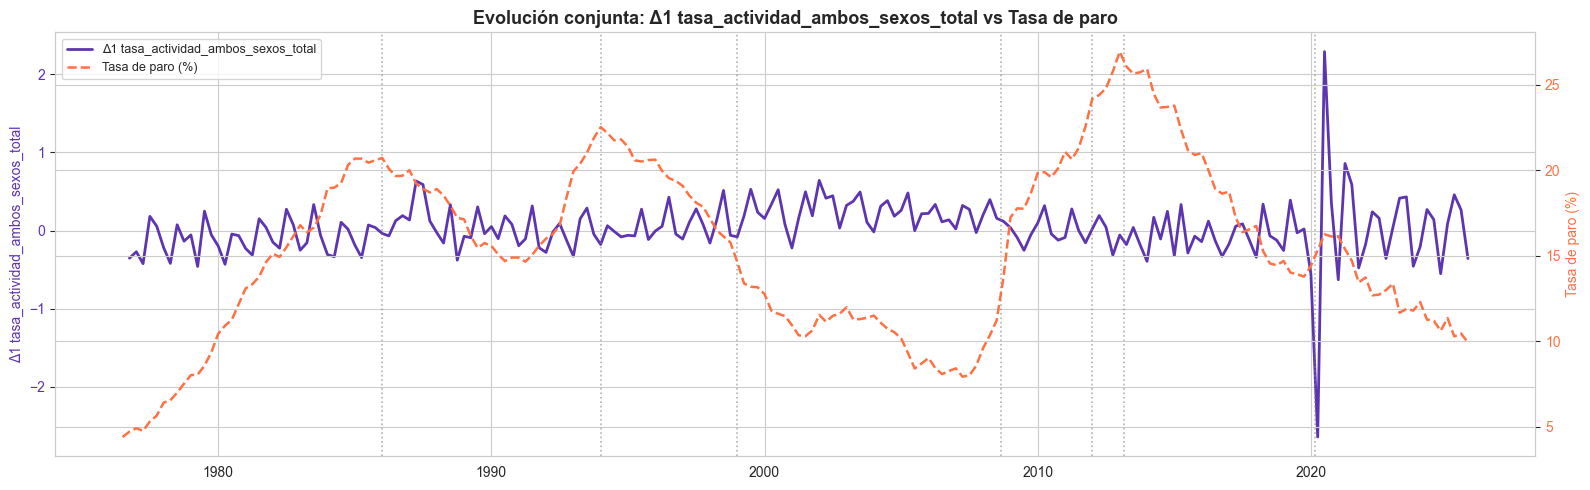

In [25]:
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.plot(main_s9.index, main_s9, color=COLOR_PRINCIPAL, lw=2,
         label=main_s9_label)
ax2.plot(parados_aligned.index, parados_aligned, color='#FF7043',
         lw=1.8, linestyle='--', label='Tasa de paro (%)')

ax1.set_ylabel(main_s9_label, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')

for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if main_s9.index.min() <= fecha_ev <= main_s9.index.max():
        ax1.axvline(fecha_ev, color='gray', linestyle=':', lw=1.2, alpha=0.6)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.set_title(f'Evolución conjunta: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis:

La primera diferencia de la tasa de actividad oscila en torno a cero sin tendencia, confirmando que la diferenciación elimina el componente tendencial de la serie, y su co-movimiento con el nivel de la tasa de paro no presenta un patrón visual sistemático. La diferencia se mantiene mayoritariamente en un rango de aproximadamente ±0,5 puntos, con los únicos valores fuera de ese rango en 2020-Q2 (aproximadamente -2,6) y su rebote en 2020-Q3 (aproximadamente +2,3). La tasa de paro recorre en paralelo sus tres ciclos completos, pero sin que la primera diferencia anticipe ni acompañe de forma apreciable esos movimientos a simple vista. La ausencia de un acoplamiento visible entre una serie estacionaria que fluctúa alrededor de cero y un nivel de paro de comportamiento cíclico es coherente con una relación contemporánea débil, que los paneles siguientes cuantifican.

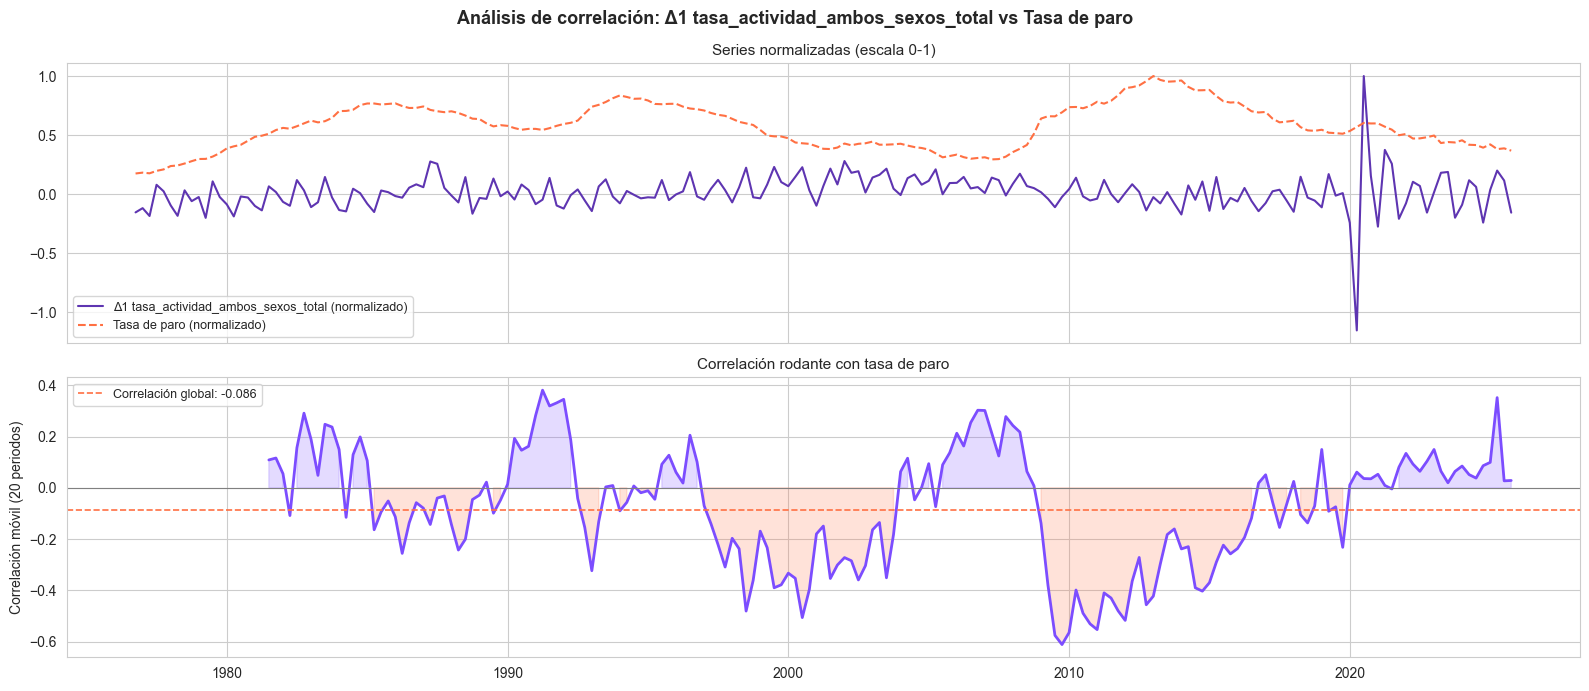

Correlación de Pearson global: -0.0857


In [26]:
ventana_corr = 20

df_cross = pd.DataFrame({'tasa_actividad': main_s9, 'parados': parados_aligned}).dropna()
rolling_corr = df_cross['tasa_actividad'].rolling(ventana_corr).corr(df_cross['parados'])
corr_global = df_cross['tasa_actividad'].corr(df_cross['parados'])

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(df_cross.index, df_cross['tasa_actividad'] / df_cross['tasa_actividad'].max(),
             color=COLOR_PRINCIPAL, lw=1.5, label=f'{main_s9_label} (normalizado)')
axes[0].plot(df_cross.index, df_cross['parados'] / df_cross['parados'].max(),
             color='#FF7043', lw=1.5, linestyle='--', label='Tasa de paro (normalizado)')
axes[0].legend(fontsize=9)
axes[0].set_title('Series normalizadas (escala 0-1)', fontsize=11)

axes[1].plot(rolling_corr.index, rolling_corr, color='#7C4DFF', lw=2)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].axhline(corr_global, color='#FF7043', lw=1.2, linestyle='--',
                label=f'Correlación global: {corr_global:.3f}')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr > 0, alpha=0.2, color='#7C4DFF')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr < 0, alpha=0.2, color='#FF7043')
axes[1].set_ylabel(f'Correlación móvil ({ventana_corr} periodos)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_title('Correlación rodante con tasa de paro', fontsize=11)

fig.suptitle(f'Análisis de correlación: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Correlación de Pearson global: {corr_global:.4f}')

### Análisis:

La correlación de Pearson global entre la primera diferencia de la tasa de actividad y la tasa de paro es de -0,0857, débilmente negativa y estadísticamente indistinguible de cero. Esta cifra global, sin embargo, oculta un comportamiento dependiente del régimen: la correlación rodante a 20 periodos alterna de signo y cruza el cero en numerosas ocasiones, recorriendo un rango amplio desde aproximadamente -0,6 hasta aproximadamente +0,4. Los tramos de correlación negativa fuerte y estable se concentran en 2008-2014, en torno a aproximadamente -0,6, y en el cambio de siglo, alrededor de aproximadamente -0,5, mientras que aparecen ventanas de correlación positiva en los primeros 90, a mediados de los 2000 y en los años más recientes, de aproximadamente +0,3 a +0,4.

La proximidad a cero de la correlación global no justifica descartar la variable: la existencia de ventanas prolongadas con signo estable indica poder predictivo condicionado al régimen, que se diluye al promediar sobre toda la muestra. Este resultado cuantifica la inestabilidad de signo que ya se apreciaba en la comparación de niveles, donde la relación entre participación y paro cambiaba según el tramo.

In [27]:
df_cross['decada'] = (df_cross.index.year // 10 * 10).astype(str) + 's'
paleta_decadas = ['#1565C0', '#00897B', '#FF7043', '#7C4DFF', '#FFC107', '#AD1457']

df_scatter = df_cross.reset_index().rename(columns={'index': 'fecha', df_cross.index.name or 'index': 'fecha'})
if 'fecha' not in df_scatter.columns:
    df_scatter.insert(0, 'fecha', df_cross.index.strftime('%Y-%m-%d'))
else:
    df_scatter['fecha'] = pd.to_datetime(df_scatter['fecha']).dt.strftime('%Y-%m-%d')

fig = px.scatter(
    df_scatter, x='tasa_actividad', y='parados',
    color='decada',
    hover_data=['fecha'],
    trendline='ols',
    trendline_scope='overall',
    color_discrete_sequence=paleta_decadas,
    title=f'Dispersión por década: {main_s9_label} vs Tasa de paro',
    labels={
        'tasa_actividad': main_s9_label,
        'parados': 'Tasa de paro (%)',
        'decada': 'Década', 'fecha': 'Fecha',
    },
)
fig.for_each_trace(lambda t: t.update(name='Tendencia global') if t.name == 'Overall Trendline' else None)
fig.update_traces(marker=dict(size=6, opacity=0.75))
fig.update_layout(height=520)
fig.show()

### Análisis:

La dispersión por décadas reproduce la debilidad de la relación contemporánea, con una tendencia global de pendiente ligeramente negativa que va desde aproximadamente 18,5% de paro en el extremo de primera diferencia -2 hasta aproximadamente 13% en el extremo +2. La nube de puntos se concentra en torno a una primera diferencia próxima a cero y cubre todo el rango de paro, desde aproximadamente 5% hasta aproximadamente 27%. Las décadas se estratifican verticalmente según el régimen de paro: los años 70 en la banda baja, aproximadamente 5-10%, los 80, 90 y 2010 en la banda alta, por encima del 18%, y los 2000 y 2020 en posiciones intermedias. En cambio, no hay separación horizontal por década, es decir, la magnitud del cambio trimestral de la participación es similar en todos los regímenes. La lectura es que el nivel de paro viene determinado por el régimen cíclico de cada periodo y no por la variación contemporánea de la actividad, coherente con la correlación global de -0,0857.

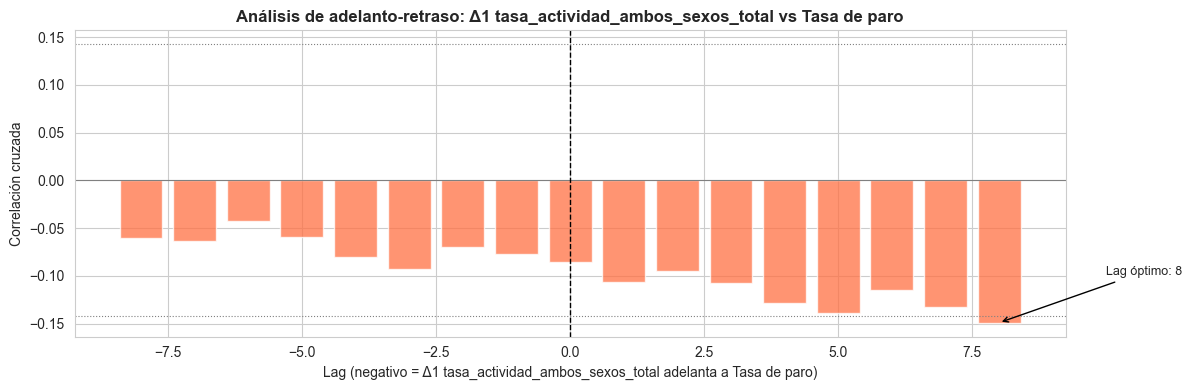

Lag con máxima correlación: 8 periodos
Correlación en ese lag: -0.1490
Banda de significancia (±2/√N): ±0.1425


In [28]:
max_lag = LAGS_ACF // 2

sa = (df_cross['tasa_actividad'] - df_cross['tasa_actividad'].mean()) / df_cross['tasa_actividad'].std()
sb = (df_cross['parados'] - df_cross['parados'].mean()) / df_cross['parados'].std()

lags_range = range(-max_lag, max_lag + 1)
ccf_vals = [sa.corr(sb.shift(-lag)) for lag in lags_range]

fig, ax = plt.subplots(figsize=(12, 4))
colors_ccf = ['#00897B' if v > 0 else '#FF7043' for v in ccf_vals]
ax.bar(list(lags_range), ccf_vals, color=colors_ccf, alpha=0.75)
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='black', lw=1, linestyle='--')
sig = 2 / np.sqrt(len(df_cross))
ax.axhline(sig, color='gray', lw=0.8, linestyle=':')
ax.axhline(-sig, color='gray', lw=0.8, linestyle=':')

lag_max = list(lags_range)[np.argmax(np.abs(ccf_vals))]
ax.annotate(f'Lag óptimo: {lag_max}', xy=(lag_max, ccf_vals[lag_max + max_lag]),
            xytext=(lag_max + 2, ccf_vals[lag_max + max_lag] + 0.05),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel(f'Lag (negativo = {main_s9_label} adelanta a Tasa de paro)', fontsize=10)
ax.set_ylabel('Correlación cruzada', fontsize=10)
ax.set_title(f'Análisis de adelanto-retraso: {main_s9_label} vs Tasa de paro', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Lag con máxima correlación: {lag_max} periodos')
print(f'Correlación en ese lag: {ccf_vals[lag_max + max_lag]:.4f}')
print(f'Banda de significancia (±2/√N): ±{sig:.4f}')

### Análisis:

Ningún adelanto o retraso de corto plazo alcanza significancia: la única correlación que supera la banda lo hace a un horizonte largo de ocho trimestres. La correlación contemporánea, de -0,0857, queda dentro de la banda de significancia de ±0,1425, igual que los lags operativos de 1 a 4 periodos, todos no significativos. El máximo de correlación cruzada se da en el lag 8, con -0,149, que rebasa por muy poco la banda. Según la convención del gráfico, donde un lag negativo indica que la primera diferencia de la actividad antecede al paro, este óptimo en lag positivo implica que es la tasa de paro la que antecede a la primera diferencia de la actividad en ocho trimestres.

Se trata por tanto de una relación descriptiva de largo plazo, de dos años de horizonte y magnitud marginal, sin utilidad operativa para la predicción de corto plazo de la tasa de paro. La ausencia de lags cortos significativos refuerza que el valor de esta variable, si lo tiene, reside en su correlación condicionada al régimen y no en una relación de adelanto contemporánea o de pocos trimestres.